# Load metrics files for each version of a given experiment, and summarize performance in various tables

In [1]:
import pandas as pd
from functools import reduce
import ast
import numpy as np
import pyvista as pv
import json
from pathlib import Path
from utils.metrics import estimate_typical_distance
from config import METRICS_DIR, PATIENT_MESHES_DIR

2026-02-19 17:45:46.623 | INFO     | config:<module>:6 - PROJ_ROOT path is: /home/navarri/AtriaProject/deepcsdf-atria


In [2]:
# sometimes I saved single metrics (like LDDMM) as [value], so I need to have it as single value ...
def parse_value(x):
    # numpy array or list from LDDMM
    if isinstance(x, (np.ndarray, list, tuple)):
        return float(x[0])
    if isinstance(x, str):
        return float(ast.literal_eval(x)[0])
    # scalar from chamfer or haussdorff
    return float(x)

# for styling tables
def highlight_overall_best(val, mask):
    return 'background-color: orange' if mask else ''

def highlight_top3(val, rank):
    if rank == 1:
        return 'background-color: orange'
    elif rank == 2:
        return 'background-color: gray'
    elif rank == 3:
        return 'background-color: peru'  # bronze-ish color
    else:
        return ''
    
def style_table_top3_per_column(use_table, display_table):
    # Extract only mean values for comparison
    table_means = use_table.xs('mean', axis=1, level=1)
    # Best lambda_reg per column (per organ)
    best_mask = table_means.eq(table_means.min(axis=0), axis=1)
    # Rank the values per column (ascending because lower is better)
    ranks = table_means.rank(method='min', axis=0)  # smallest = rank 1

    table_styled = display_table.style.apply(
        lambda row: [
            highlight_top3(v, ranks.loc[row.name, col])
            for col, v in zip(table_means.columns, row)
        ],
        axis=1
    )

    return table_styled

def style_table_overall_best(use_table, display_table):
    # Extract only mean values for comparison
    table_means = use_table.xs('mean', axis=1, level=1)
    # Find the absolute minimum across the whole table
    overall_min = table_means.min().min()
    # Boolean mask where True indicates the overall best value
    best_mask = table_means == overall_min
    # Apply styling
    table_styled = display_table.style.apply(
        lambda row: [
            highlight_overall_best(v, best_mask.loc[row.name, col])
            for col, v in zip(table_means.columns, row)
        ],
        axis=1
    )
  
    return table_styled

def combine_table(table):

    table_combined = pd.DataFrame(index=table.index)

    for organ in table.columns.levels[0]:
        mean_col = (organ, 'mean')
        std_col = (organ, 'std')
        
        # Format as "mean ± std"
        table_combined[organ] = (
            table[mean_col].round(4).astype(str) + " ± " + table[std_col].round(4).astype(str)
        )

    return table_combined


In [3]:
def get_tables_meanstd_per_organ(df, index):

    table = (
        df
        .pivot_table(
            index=index, # ["lipschitz_lays", "code_reg"],   # can accept multi-index rows ["column label 1", "column label 2"] or single ones
            columns="organ",
            values=["mean", "std"],
            aggfunc="mean"
        )
        .sort_index()
        .swaplevel(axis=1)
        .sort_index(axis=1)
    )

    table_combined = combine_table(table)

    return table, table_combined

def get_tables_meanstd_overall(df, index, columns):


    table = (
        df
        .pivot_table(
            index=index,   # can accept multi-index rows ["column label 1", "column label 2"]
            columns=columns,
            values=["mean", "std"],
            aggfunc="mean"
        )
        .sort_index()
        .swaplevel(axis=1) # swaps organ and aggfunc, so instead of having "mean" and "std" as top level and then epi la ra for each, It's the other way around
        .sort_index(axis=1)
    )

    table_combined = combine_table(table)

    return table, table_combined


In [4]:
experiment_name = "LipLayersAndCodeReg"
exp_subdir = ""
which_shapes = "test"

In [5]:
# for these experiments, names are just like {version}-{experiment_name}-{metric}-{opt}.parquet
# retrieve all the wanted files
dfs = []

for file_path in list( METRICS_DIR.glob(f"{experiment_name}*{which_shapes}.csv") ):
    df = pd.read_csv(file_path)

    # go fetch the specs file to add columns I need to differentiate versions
    version = file_path.stem.split("-")[1].split("_")[-1]    
    
    df["version"] = int(version)

    with open(f"experiments/{experiment_name}/version_{version}/hparams.json") as f:
        specs = json.load(f)

    # this has to be changed manually for what is wanted ...
    df["lipschitz_lays"] = str( specs["Network_specs"]["lipschitz_layers"] )
    df["code_reg"] = specs["code_reg_lambda"]
    # df["num_steps"] = specs["NumEpochs"] * np.floor( 89 / specs["batch_size"] )
    # anneal = specs["anneal_reg_loss"]
    # df["anneal"] = anneal 
    
    dfs.append(df)

df_all = pd.concat(dfs, ignore_index=True)

df_all["value"] = df_all["value"].apply(parse_value)

df_all

,version,patient,organ,metric,value,lipschitz_lays,code_reg
0,12,AF024,epicardium,haussdorff,0.181883,"[3, 4]",0.000001
1,12,AF024,la_endo,haussdorff,0.184934,"[3, 4]",0.000001
2,12,AF024,ra_endo,haussdorff,0.136527,"[3, 4]",0.000001
3,12,LEU_NORM_0891,epicardium,haussdorff,0.110977,"[3, 4]",0.000001
4,12,LEU_NORM_0891,la_endo,haussdorff,0.128984,"[3, 4]",0.000001
...,...,...,...,...,...,...,...
3307,5,AF006,la_endo,chamfer,0.092799,"[2, 3, 4]",0.001000
3308,5,AF006,ra_endo,chamfer,0.071290,"[2, 3, 4]",0.001000
3309,5,AF001,epicardium,chamfer,0.070738,"[2, 3, 4]",0.001000
3310,5,AF001,la_endo,chamfer,0.058816,"[2, 3, 4]",0.001000


# Rescale metrics 
Values of all metrics are computed on the meshes at their standardized scale. Chamfer and Haussdorff can easily be rescaled to any wanted physical scale. LDDMM can be rescaled just for display reason, since too small values look 0 practically ...

Additionally, for now I have used meshes in training standardized to REMOVE relative dimension! So I just manually bring meshes to their real scale, also reintroducing clearly relative size, but I have to note that the real network output is not modelling this information. So it may perform "the same" on shapes with different dimension because in reality they were reconstructed at the same scale, but it does not mean the network is capable of discerning relative volume, in fact, it cannot be since I didn't give it this information during training. **This is just to have the metrics value in a physical scale rather than adimensional and very small since standardized meshes are at unit scale**

In [6]:
scale_lddmm_for_display = 100.0

patients = df_all["patient"].unique()
organs = df_all["organ"].unique()
rows = [] 
for patient in patients: 
    for organ in organs:
        # retrieve carachteristic scale per patient, per organ, from original mesh, in the same scale in which I computed METRICS !!
        mesh_orig = pv.read(PATIENT_MESHES_DIR / patient / f"{organ}-processed.vtp")

        # ---- original scale, micrometers ---- #
        scale = mesh_orig.field_data["scale-tooriginalrange"][0]

        scale_millimeters = float(scale) * 0.001  # µm → mm

        # mesh_orig.points *= scale_millimeters

        # typical_mesh_distance = estimate_typical_distance(mesh_orig) # around 400 - 500 for meshes in micrometers, 0.400 - 0.500 for mesh in millimeters ...
        
        rows.append(
            {
                "patient": patient,
                "organ": organ,
                "scaling": scale_millimeters
            }
        )

df_scale_len = pd.DataFrame(rows)

df_all_chd = df_all.query(" metric == 'chamfer' ").drop(columns="metric")
df_all_hsd = df_all.query(" metric == 'haussdorff' ").drop(columns="metric")
df_all_lddmm = df_all.query(" metric == 'LDDMM' ").drop(columns="metric")

df_all_chd = df_all_chd.merge(df_scale_len, on=["patient", "organ"], how="left")
df_all_hsd = df_all_hsd.merge(df_scale_len, on=["patient", "organ"], how="left")

# both chamfer and haussdorf are LINEAR in distance from how I compute them, LDDMM is already computed in the scale I want since I can't rescale it after...
df_all_chd["value_scaled"] = df_all_chd["value"] * df_all_chd["scaling"]
df_all_hsd["value_scaled"] = df_all_hsd["value"] * df_all_hsd["scaling"]
df_all_lddmm["value_scaled"] = df_all_lddmm["value"] * scale_lddmm_for_display

## Compute mean and std over all patients for each version and for each organ

In [7]:
groupby_keep = ["organ", "lipschitz_lays", "code_reg"]

df_chd = df_all_chd.groupby(groupby_keep)["value_scaled"].agg( 
    mean="mean",
    std="std"
).reset_index()

df_hsd = df_all_hsd.groupby(groupby_keep)["value_scaled"].agg( 
    mean="mean",
    std="std"
).reset_index()

df_lddmm = df_all_lddmm.groupby(groupby_keep)["value_scaled"].agg( 
    mean="mean",
    std="std"
).reset_index()

### Style into a table, highlight best values

In [8]:
df = df_chd
table, table_combined = get_tables_meanstd_per_organ(df, index = ["lipschitz_lays", "code_reg"])
table_styled = style_table_top3_per_column(table, table_combined)
print(f"Chamfer on {which_shapes}")
table_styled

Chamfer on test


In [9]:
df = df_hsd
table, table_combined = get_tables_meanstd_per_organ(df, index = ["lipschitz_lays", "code_reg"])
table_styled = style_table_top3_per_column(table, table_combined)
print(f"Haussdorff on {which_shapes}")
table_styled

Haussdorff on test


In [10]:
df = df_lddmm
table, table_combined = get_tables_meanstd_per_organ(df, index = ["lipschitz_lays", "code_reg"])
table_styled = style_table_top3_per_column(table, table_combined)
print(f"LDDMM on {which_shapes}")
table_styled

LDDMM on test


## Groups also over all organs per patient

In [22]:
groupby_keep = ["lipschitz_lays", "code_reg"]

df_chd = df_all_chd.groupby(groupby_keep)["value_scaled"].agg( 
    mean="mean",
    std="std"
).reset_index()

df_hsd = df_all_hsd.groupby(groupby_keep)["value_scaled"].agg( 
    mean="mean",
    std="std"
).reset_index()

df_lddmm = df_all_lddmm.groupby(groupby_keep)["value_scaled"].agg( 
    mean="mean",
    std="std"
).reset_index()

In [21]:
df = df_chd
table, table_combined = get_tables_meanstd_overall(df, index = "lipschitz_lays", columns = "code_reg")
table_styled = style_table_overall_best(table, table_combined)
print(f"Chamfer on {which_shapes}")
table_styled

Chamfer on test


,0.000001,0.000010,0.000100,0.001000
lipschitz_lays,,,,
[-1],2.8515 ± 0.6782,2.7712 ± 0.6973,2.9508 ± 0.9203,3.6473 ± 1.2092
"[0, 1, 2, 3, 4]",3.6991 ± 1.0446,4.1167 ± 1.2671,6.6115 ± 2.1016,11.9659 ± 2.4321
"[2, 3, 4]",3.3989 ± 1.1839,3.1756 ± 0.8703,3.6803 ± 0.9298,4.821 ± 1.1818
"[3, 4]",3.1457 ± 0.8664,2.9122 ± 0.7526,3.3293 ± 0.857,4.587 ± 1.3571


In [13]:
df = df_hsd
table, table_combined = get_tables_meanstd_overall(df, index = "lipschitz_lays", columns = "code_reg")
table_styled = style_table_overall_best(table, table_combined)
print(f"Haussdorff on {which_shapes}")
table_styled

Haussdorff on test


,0.000001,0.000010,0.000100,0.001000
lipschitz_lays,,,,
[-1],9.6911 ± 3.6407,10.6996 ± 4.5541,12.0123 ± 6.3852,13.2314 ± 4.8353
"[0, 1, 2, 3, 4]",13.3095 ± 4.1492,13.6454 ± 3.8019,20.8724 ± 7.2873,29.2545 ± 7.099
"[2, 3, 4]",10.7128 ± 4.1469,11.3942 ± 3.2367,12.2803 ± 3.6364,15.4094 ± 4.516
"[3, 4]",10.2747 ± 4.1111,11.2471 ± 4.0836,11.5164 ± 3.8031,14.8296 ± 4.3313


In [14]:
df = df_lddmm
table, table_combined = get_tables_meanstd_overall(df, index = "lipschitz_lays", columns = "code_reg")
table_styled = style_table_overall_best(table, table_combined)
print(f"LDDMM on {which_shapes}")
table_styled

LDDMM on test


,0.000001,0.000010,0.000100,0.001000
lipschitz_lays,,,,
[-1],3.6326 ± 19.4535,3.6493 ± 19.3125,4.384 ± 19.8548,4.7446 ± 18.1644
"[0, 1, 2, 3, 4]",4.841 ± 17.8188,6.3187 ± 17.4723,12.3136 ± 18.6963,34.9277 ± 38.7362
"[2, 3, 4]",4.0003 ± 20.0073,4.0884 ± 19.258,4.0283 ± 19.412,5.6375 ± 18.2103
"[3, 4]",3.7776 ± 19.8688,3.7327 ± 19.3058,4.0908 ± 19.2922,5.7471 ± 18.247


# Some PLOTS instead of boring tables

For a given table that summarize one overall metric per parameters combination, I could do a 2D plot with several scattered lines: fix one param as just label of the curve, then scatter the other param VS metric value. 

In [15]:
import matplotlib.pyplot as plt

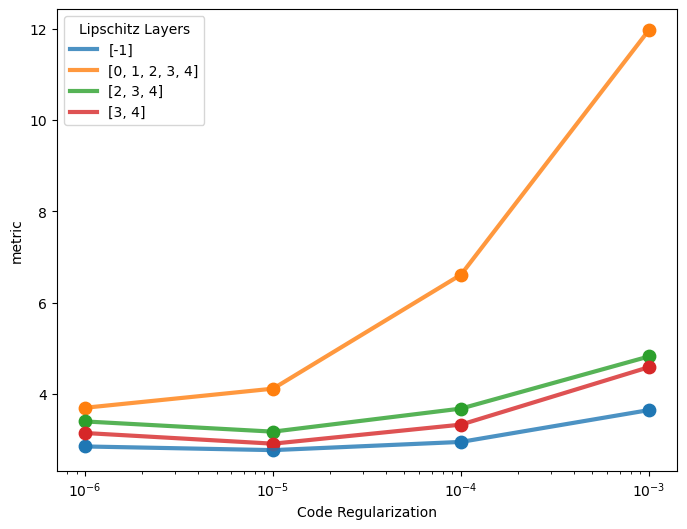

In [26]:
df = df_chd
metric = "metric"

plt.figure(figsize=(8,6))

# Unique Lipschitz layers for line labels/colors
layers = df['lipschitz_lays'].unique()

# Plot each layer separately
for layer in layers:
    subset = df[df['lipschitz_lays'] == layer]
    plt.plot(subset['code_reg'], subset['mean'], linewidth=3.0, alpha=0.8, label=layer)
    plt.scatter(subset['code_reg'], subset['mean'], s = 80)
    # Optional: add error bars
    # plt.errorbar(subset['code_reg'], subset['mean'], yerr=subset['std'], fmt='o', capsize=3)

plt.xscale('log')
plt.xlabel("Code Regularization")
plt.ylabel(f"{metric}")
plt.legend(title="Lipschitz Layers")
plt.show()